# Exploration : Remplissage des matchs Paris Basketball

Question métier : quels matchs sous-performent en remplissage, et quels
leviers (tarification, campagnes, timing) pourraient corriger ça ?

Ce notebook explore `gold.fact_match`, construite par le pipeline
(`pipeline/gold/build_gold.py`), qui contient une ligne par match à domicile
avec le taux de remplissage, le contexte sportif, temporel et météo.

In [3]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

con = duckdb.connect("../data/warehouse/pbb.duckdb")
df = con.execute("SELECT * FROM gold.fact_match ORDER BY date").fetchdf()
print(f"{len(df)} matchs chargés")
df.head()

41 matchs chargés


,match_id,date,heure,competition,journee,adversaire,salle,capacite_salle,billets_vendus,taux_remplissage,revenu_billetterie,prix_moyen_billet,billets_abonnement,billets_unite,part_billets_unite,billets_annules,billets_rembourses,billets_en_attente,taux_annulation,entrees_ok,taux_presence,rang_pbb_avant,rang_adversaire_avant,ecart_classement,score_domicile,score_exterieur,victoire_pbb,jour_semaine,vacances_scolaires,temperature,precipitation
0,M001,2025-10-09,20:45:00,EuroLeague,3,Virtus Bologna,ADIDAS,8000,5173,0.647,327608.62,63.33,2538.0,2164.0,0.418,48,19,137,0.009,4718,0.912,6,17,11,90,79,1,Thursday,False,15.9,0.0
1,M002,2025-10-12,17:00:00,Betclic ÉLITE,3,Monaco,ADIDAS,8000,6746,0.843,378803.40,56.15,2538.0,3446.0,0.511,93,28,132,0.013,6154,0.912,10,4,-6,94,99,0,Sunday,False,17.1,0.0
2,M003,2025-10-15,20:45:00,EuroLeague,4,Kosner Baskonia Vitoria-Gasteiz,ADIDAS,8000,5539,0.692,346957.11,62.64,2538.0,2412.0,0.435,94,49,122,0.016,5085,0.918,4,20,16,105,87,1,Wednesday,False,13.9,0.0
3,M004,2025-10-17,20:45:00,EuroLeague,5,Hapoel Shlomo Tel Aviv,ADIDAS,8000,7577,0.947,536570.44,70.82,2538.0,4200.0,0.554,96,52,195,0.012,6986,0.922,5,10,5,88,89,0,Friday,True,13.2,0.0
4,M005,2025-10-19,14:30:00,Betclic ÉLITE,4,Dijon,ADIDAS,8000,3236,0.405,130772.28,40.41,2538.0,561.0,0.173,8,4,81,0.002,2929,0.905,6,13,7,97,92,1,Sunday,True,13.3,0.0


## 1. Vue d'ensemble du remplissage

In [4]:
print(df['taux_remplissage'].describe())
print()
print("Par compétition :")
print(df.groupby('competition')['taux_remplissage'].agg(['mean', 'min', 'max', 'count']).round(3))

count    41.000000
mean      0.799683
std       0.124957
min       0.405000
25%       0.747000
50%       0.813000
75%       0.905000
max       0.951000
Name: taux_remplissage, dtype: float64

Par compétition :
                           mean    min    max  count
competition                                         
Betclic ÉLITE             0.746  0.405  0.886     15
Betclic ÉLITE - Playoffs  0.847  0.703  0.935      7
EuroLeague                0.825  0.560  0.951     19


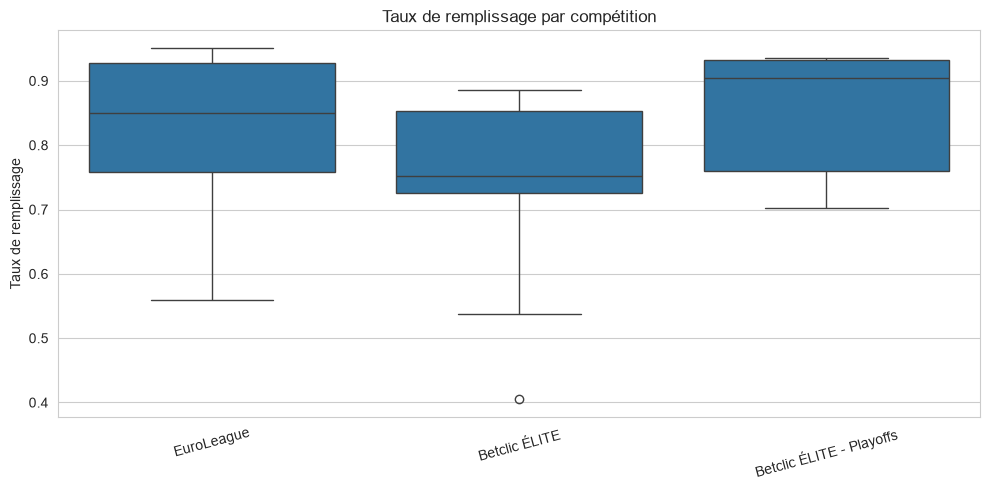

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='competition', y='taux_remplissage', ax=ax)
ax.set_title("Taux de remplissage par compétition")
ax.set_ylabel("Taux de remplissage")
ax.set_xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../dashboard/fig_remplissage_par_competition.png", dpi=120)
plt.show()

## 2. Les matchs les plus faibles

Les 8 matchs avec le plus faible taux de remplissage, et leur contexte.

In [6]:
cols = ['match_id', 'date', 'adversaire', 'competition', 'taux_remplissage',
        'rang_adversaire_avant', 'jour_semaine', 'vacances_scolaires', 'temperature']
df.nsmallest(8, 'taux_remplissage')[cols]

,match_id,date,adversaire,competition,taux_remplissage,rang_adversaire_avant,jour_semaine,vacances_scolaires,temperature
4,M005,2025-10-19,Dijon,Betclic ÉLITE,0.405,13,Sunday,True,13.3
10,M011,2025-12-07,Saint-Quentin,Betclic ÉLITE,0.538,14,Sunday,False,14.4
25,M026,2026-03-12,LDLC ASVEL Villeurbanne,EuroLeague,0.560,20,Thursday,False,10.5
11,M012,2025-12-09,Le Portel,Betclic ÉLITE,0.607,16,Tuesday,False,14.2
0,M001,2025-10-09,Virtus Bologna,EuroLeague,0.647,17,Thursday,False,15.9
2,M003,2025-10-15,Kosner Baskonia Vitoria-Gasteiz,EuroLeague,0.692,20,Wednesday,False,13.9
34,M035,2026-05-26,Strasbourg,Betclic ÉLITE - Playoffs,0.703,22,Tuesday,False,30.8
21,M022,2026-02-01,Boulazac,Betclic ÉLITE,0.711,12,Sunday,False,8.4


## 3. Le classement de l'adversaire a-t-il un effet ?

Hypothèse formée à l'oeil sur les données : un adversaire mal classé
(rang élevé) semble associé à un taux de remplissage plus faible.

In [7]:
corr = df[['taux_remplissage', 'rang_adversaire_avant', 'rang_pbb_avant', 'ecart_classement']].corr()
print(corr['taux_remplissage'])

taux_remplissage         1.000000
rang_adversaire_avant   -0.625786
rang_pbb_avant           0.330336
ecart_classement        -0.623212
Name: taux_remplissage, dtype: float64


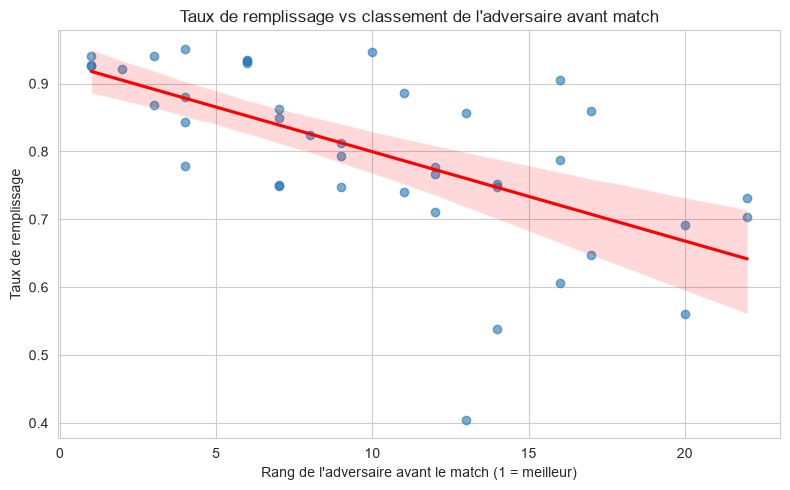

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x='rang_adversaire_avant', y='taux_remplissage', ax=ax,
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
ax.set_title("Taux de remplissage vs classement de l'adversaire avant match")
ax.set_xlabel("Rang de l'adversaire avant le match (1 = meilleur)")
ax.set_ylabel("Taux de remplissage")
plt.tight_layout()
plt.savefig("../dashboard/fig_remplissage_vs_classement.png", dpi=120)
plt.show()

## 4. Jour de semaine et vacances scolaires

In [9]:
print(df.groupby('jour_semaine')['taux_remplissage'].agg(['mean', 'count']).round(3).sort_values('mean'))
print()
print(df.groupby('vacances_scolaires')['taux_remplissage'].agg(['mean', 'count']).round(3))

               mean  count
jour_semaine              
Sunday        0.748     10
Saturday      0.803      5
Thursday      0.810     12
Wednesday     0.813      2
Tuesday       0.819     11
Friday        0.947      1

                     mean  count
vacances_scolaires              
False               0.810     34
True                0.752      7


**Vérification** : l'effet "vacances scolaires" pourrait n'être qu'un
artefact si le calendrier programmait par coïncidence des adversaires plus
faibles pendant les vacances. On vérifie ici que ce n'est pas le cas.

In [10]:
print(df.groupby('vacances_scolaires')['rang_adversaire_avant'].mean())

vacances_scolaires
False    10.088235
True      9.571429
Name: rang_adversaire_avant, dtype: float64


## 5. Prix moyen du billet vs remplissage

Le prix a-t-il été ajusté à la baisse pour les matchs à faible affluence
anticipée, ou est-ce un effet a posteriori (moins de monde = moins
d'abonnés, qui paient un tarif différent) ?

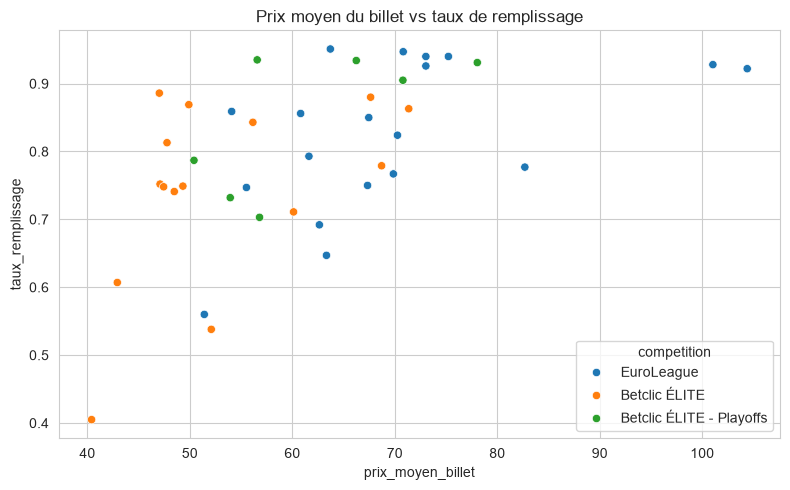

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='prix_moyen_billet', y='taux_remplissage', hue='competition', ax=ax)
ax.set_title("Prix moyen du billet vs taux de remplissage")
plt.tight_layout()
plt.savefig("../dashboard/fig_prix_vs_remplissage.png", dpi=120)
plt.show()

## 6. Effet de la météo

La météo (température, précipitations) a été collectée pour chaque match
mais pas encore explorée. Vérifions si elle influence le remplissage.

In [12]:
corr_meteo = df[['taux_remplissage', 'temperature', 'precipitation']].corr()
print(corr_meteo['taux_remplissage'])
print()
print("Matchs avec précipitations :", (df['precipitation'] > 0).sum())
print(df.groupby(df['precipitation'] > 0)['taux_remplissage'].agg(['mean', 'count']))

taux_remplissage    1.000000
temperature         0.037348
precipitation       0.024387
Name: taux_remplissage, dtype: float64

Matchs avec précipitations : 9
                   mean  count
precipitation                 
False          0.788188     32
True           0.840556      9


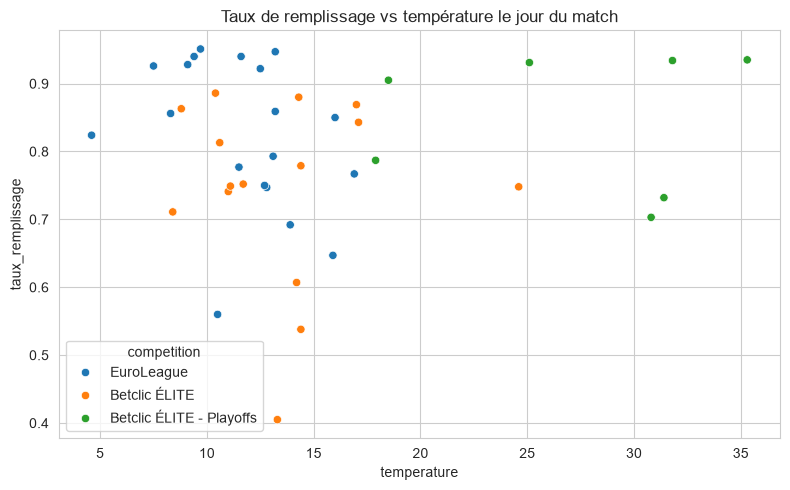

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='temperature', y='taux_remplissage', hue='competition', ax=ax)
ax.set_title("Taux de remplissage vs température le jour du match")
plt.tight_layout()
plt.savefig("../dashboard/fig_meteo_vs_remplissage.png", dpi=120)
plt.show()

## 7. Annulations et remplissage

Utilisation d'une donnée jusqu'ici inexploitée : les commandes annulées
(order_status_id) en billetterie brute, au-delà des seuls billets validés.

In [14]:
corr_annulation = con.execute("""
    SELECT CORR(taux_remplissage, taux_annulation) AS correlation
    FROM gold.fact_match WHERE taux_annulation IS NOT NULL
""").fetchdf()
print(corr_annulation)
print()
print(df['taux_annulation'].describe())

   correlation
0     0.615886

count    41.000000
mean      0.012122
std       0.003509
min       0.002000
25%       0.010000
50%       0.012000
75%       0.015000
max       0.018000
Name: taux_annulation, dtype: float64


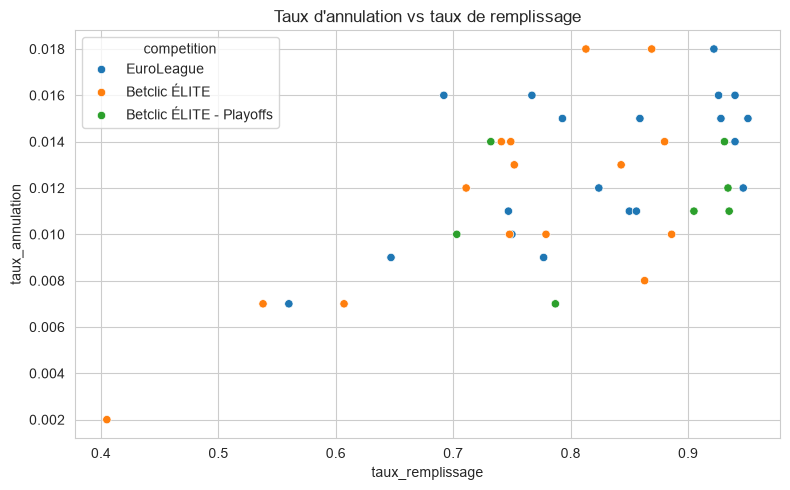

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='taux_remplissage', y='taux_annulation', hue='competition', ax=ax)
ax.set_title("Taux d'annulation vs taux de remplissage")
plt.tight_layout()
plt.savefig("../dashboard/fig_annulation_vs_remplissage.png", dpi=120)
plt.show()

## 8. Satisfaction et remplissage

Croisement de silver.satisfaction (jusqu'ici inutilisée) avec le remplissage.
Un clivage net entre matchs à forte satisfaction (~8+) et faible (~6-6.5)
a été investigué : ni la compétition, ni le type d'enquête, ni la période
de la saison, ni le canal de réponse ne l'expliquent.

**La vraie cause : le résultat du match.** Satisfaction moyenne de 8.14
en victoire contre 6.20 en défaite. Or la victoire est elle-même corrélée
négativement au remplissage (-0.45) : Paris gagne plus souvent quand la
salle est moins remplie, précisément parce que ces matchs sont contre des
adversaires plus faibles (déjà identifié section 3). Remplissage et
satisfaction ne sont donc pas directement liés -- tous deux sont des
conséquences du niveau de l'adversaire.

In [30]:
print(con.execute("""
    SELECT victoire_pbb, AVG(note_globale) AS note_moyenne, COUNT(*) AS n_reponses
    FROM gold.fact_match f
    JOIN silver.satisfaction s ON f.match_id = s.match_id
    WHERE s.type_enquete = 'POST_MATCH'
    GROUP BY victoire_pbb
""").fetchdf())

   victoire_pbb  note_moyenne  n_reponses
0             0      6.204426        3615
1             1      8.141442        4341


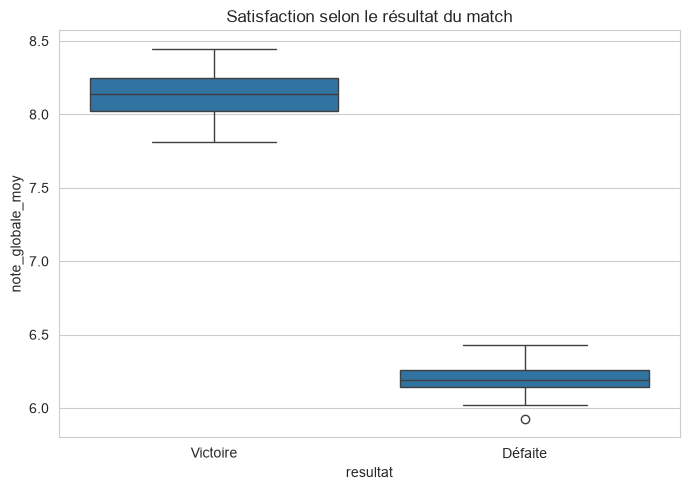

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_satisf.assign(resultat=df_satisf['victoire_pbb'].map({1:'Victoire', 0:'Défaite'})),
            x='resultat', y='note_globale_moy', ax=ax)
ax.set_title("Satisfaction selon le résultat du match")
plt.tight_layout()
plt.savefig("../dashboard/fig_satisfaction_vs_resultat.png", dpi=120)
plt.show()

## 9. L'horaire du match influence-t-il le remplissage ?

Écart apparent net entre après-midi (73.6%) et soirée (81.3%), corrélation
heure/remplissage de 0.26. **Mais confondu avec l'effet jour de semaine** :
5 des 7 matchs d'après-midi sont des dimanches, 2 des samedis -- l'horaire
après-midi est essentiellement une reformulation du calendrier week-end,
pas un facteur indépendant. Pas assez de matchs en semaine à des horaires
non-standards (13h30-17h) pour isoler un vrai effet horaire propre.

**Conclusion : pas de nouveau facteur actionnable ici** -- le levier
pertinent reste le jour de semaine (section 4), pas l'heure en tant que
telle.

In [34]:
df['heure_minutes'] = df['heure'].apply(lambda t: t.hour * 60 + t.minute)
df['creneau'] = df['heure'].apply(lambda t: 'Après-midi' if t.hour < 18 else 'Soirée')

print(df.groupby('creneau')['taux_remplissage'].agg(['mean', 'count']))
print()
print("Corrélation heure (en minutes) vs remplissage :")
print(df[['taux_remplissage', 'heure_minutes']].corr().iloc[0,1])

                mean  count
creneau                    
Après-midi  0.736143      7
Soirée      0.812765     34

Corrélation heure (en minutes) vs remplissage :
0.26345785139988276


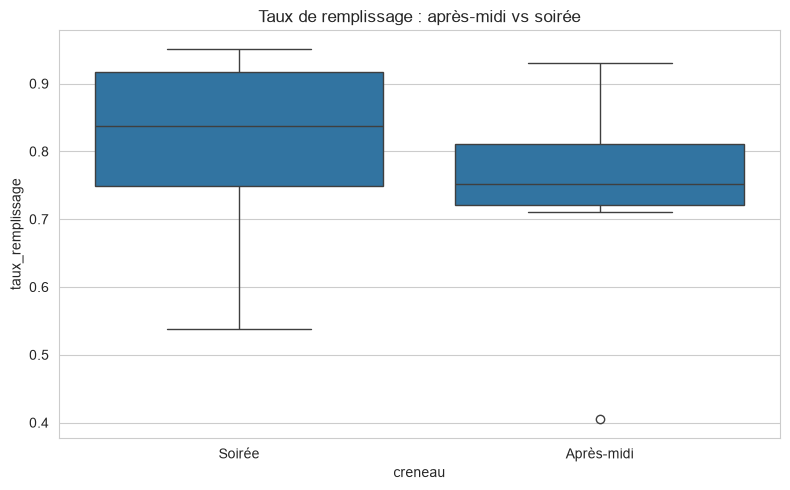

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='creneau', y='taux_remplissage', ax=ax)
ax.set_title("Taux de remplissage : après-midi vs soirée")
plt.tight_layout()
plt.savefig("../dashboard/fig_remplissage_par_creneau.png", dpi=120)
plt.show()

In [36]:
print(pd.crosstab(df['creneau'], df['jour_semaine']))

jour_semaine  Friday  Saturday  Sunday  Thursday  Tuesday  Wednesday
creneau                                                             
Après-midi         0         2       5         0        0          0
Soirée             1         3       5        12       11          2


## 10. Bassin de fans par densité démographique

Croisement de silver.contacts (code_postal) avec les données de population
(population/communes_idf, population/arrondissements_paris) : d'où viennent
réellement les fans, rapporté à la population de leur zone -- pas juste en
volume brut.

**Limite** : 25 codes postaux sur 69 dans `silver.contacts` n'ont pas de
correspondance dans les référentiels de population (probablement des fans
hors Île-de-France, ou des codes postaux fictifs issus des données de test).
L'analyse porte donc sur le bassin francilien uniquement.

In [32]:
pop_par_cp = con.execute("""
    WITH pop_brute AS (
        SELECT UNNEST(codesPostaux) AS code_postal, population
        FROM bronze.raw_population_arrondissements
        UNION ALL
        SELECT UNNEST(codesPostaux) AS code_postal, population
        FROM bronze.raw_population_communes
        WHERE nom != 'Paris'
    )
    SELECT code_postal, SUM(population) AS population
    FROM pop_brute
    GROUP BY code_postal
""").fetchdf()

contacts_par_cp = con.execute("""
    SELECT code_postal, COUNT(*) AS nb_contacts
    FROM silver.contacts WHERE code_postal IS NOT NULL
    GROUP BY code_postal
""").fetchdf()

bassin = contacts_par_cp.merge(pop_par_cp, on='code_postal', how='left')
bassin['contacts_pour_1000_hab'] = (bassin['nb_contacts'] * 1000 / bassin['population']).round(2)
bassin = bassin.dropna(subset=['population']).sort_values('contacts_pour_1000_hab', ascending=False)

print(f"{bassin['code_postal'].nunique()} codes postaux avec population connue")
print(f"{contacts_par_cp.shape[0] - bassin.shape[0]} codes postaux non matchés (hors IDF ou codes invalides)")
bassin.head(15)

44 codes postaux avec population connue
25 codes postaux non matchés (hors IDF ou codes invalides)


,code_postal,nb_contacts,population,contacts_pour_1000_hab
1,75018,12479,183127.0,68.14
54,78300,2657,40983.0,64.83
57,75019,11223,178691.0,62.81
34,93400,3154,53615.0,58.83
22,78100,2693,45931.0,58.63
32,77400,2601,48262.0,53.89
48,94800,3200,60183.0,53.17
40,93500,3201,61929.0,51.69
25,94200,3334,65064.0,51.24
28,91300,2644,51729.0,51.11


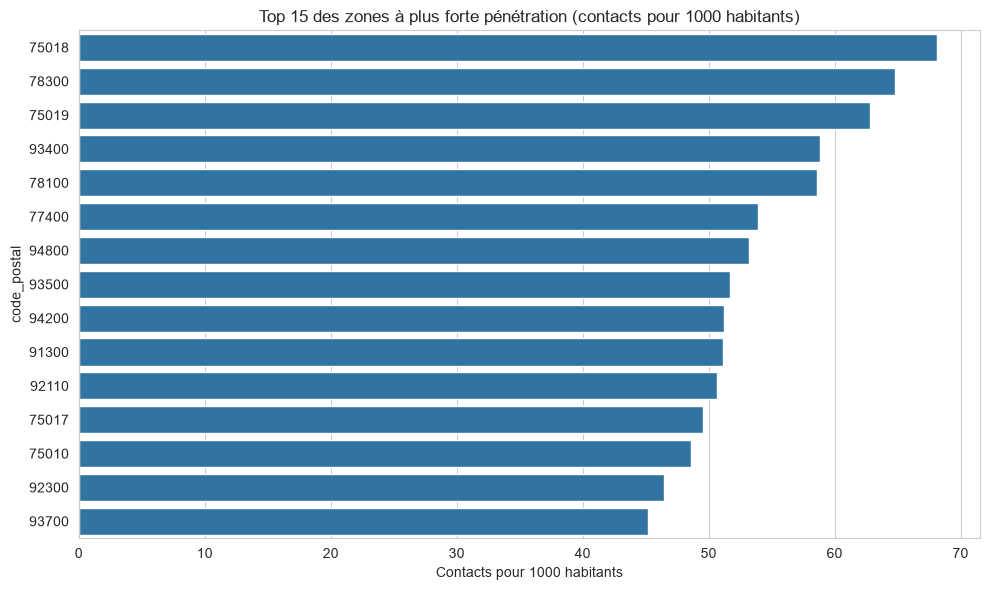

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
top15 = bassin.head(15)
sns.barplot(data=top15, y='code_postal', x='contacts_pour_1000_hab', ax=ax, orient='h',
            order=top15['code_postal'].astype(str))
ax.set_title("Top 15 des zones à plus forte pénétration (contacts pour 1000 habitants)")
ax.set_xlabel("Contacts pour 1000 habitants")
plt.tight_layout()
plt.savefig("../dashboard/fig_bassin_fans.png", dpi=120)
plt.show()

## 11. Synthèse

**Facteur dominant : le classement de l'adversaire.** Sur les 41 matchs de
la saison, le taux de remplissage chute nettement à mesure que l'adversaire
est mal classé (de ~90% pour un top adversaire à ~65% pour un adversaire en
bas de classement) -- effet net et le plus discriminant de l'analyse.

**Écart marqué par compétition** : Playoffs (84.7%) et EuroLeague (82.5%)
remplissent mieux que le championnat national Betclic ÉLITE (74.6%).

**Effet jour de semaine** : le dimanche est le jour le plus faible (74.8%,
sur 10 matchs), contre ~81-82% les mardis et jeudis.

**Effet vacances scolaires, contre-intuitif et vérifié** : les matchs
joués pendant les vacances scolaires remplissent moins bien (75.2%) que
hors vacances (81%). Vérifié : ce n'est pas un biais de calendrier (rang
adversaire moyen comparable dans les deux groupes : 9.6 vs 10.1).

**Météo : aucun effet mesurable.** Corrélation quasi nulle avec la
température (0.04) et les précipitations (0.02) -- hypothèse plausible
mais non confirmée par les données.

**Annulations plus fréquentes sur les matchs à forte demande.**
Corrélation de 0.62 entre taux de remplissage et taux d'annulation : les
matchs à forte affluence attendue génèrent davantage d'achats annulés
ensuite (achats "spéculatifs" ?), même si l'ampleur reste modeste en
absolu (0.2% à 1.8% du volume de billets).

**Horaire du match : pas de facteur indépendant.** Un écart apparent entre
après-midi et soirée s'est révélé être une reformulation de l'effet jour de
semaine (5 des 7 matchs d'après-midi sont des dimanches) -- pas un nouveau
levier actionnable.

**Satisfaction : un clivage net, dont la cause réelle a été démêlée.**
Un écart marqué entre matchs à forte satisfaction (~8+) et faible
(~6-6.5) semblait initialement lié au remplissage (corrélation -0.38).
Investigation : ni la compétition, ni le type d'enquête, ni la période de
la saison, ni le canal de réponse ne l'expliquent. La vraie cause est le
**résultat du match** (8.14 en victoire vs 6.20 en défaite), la victoire
étant elle-même corrélée négativement au remplissage (-0.45, Paris gagnant
plus souvent contre des adversaires faibles qui remplissent moins).
Remplissage et satisfaction sont donc deux conséquences distinctes du
niveau de l'adversaire, pas liées directement entre elles.

**Géomarketing : le bassin de fans est concentré au nord-est parisien.**
En rapportant le nombre de contacts à la population locale, les 18e et 19e
arrondissements dominent nettement (68 et 63 contacts pour 1000 habitants),
cohérent avec la proximité de l'Adidas Arena. Plusieurs communes de petite
couronne (Poissy, Saint-Ouen, Villejuif) affichent aussi une pénétration
forte, au-delà de Paris intra-muros.

### Recommandations actionnables

1. **Tarification dynamique par force d'adversaire** : politique tarifaire
   plus agressive pour les matchs contre des adversaires classés au-delà
   de la 15e place.
2. **Campagnes ciblées sur les dimanches et les périodes de vacances
   scolaires** : sous-performance récurrente et indépendante du calendrier
   sportif.
3. **Capitaliser sur l'attrait EuroLeague** dans la communication et le
   packaging des abonnements.
4. **Politique d'annulation adaptée aux matchs à forte demande** :
   envisager des frais d'annulation modulés ou une liste d'attente pour
   récupérer les places libérées tardivement sur les matchs premium.
5. **Marketing géolocalisé** : intensifier la présence terrain/digitale
   dans les zones à forte pénétration existante (nord-est parisien,
   Poissy, Saint-Ouen) pour consolider la base, et identifier les zones à
   fort potentiel mais faible pénétration actuelle pour de l'acquisition.

### Limites

- 41 matchs seulement : certains découpages reposent sur de petits
  échantillons (un seul match un vendredi, par exemple).
- L'analyse satisfaction porte sur ~7956 réponses `POST_MATCH` uniquement
  (deux autres types d'enquête, `GENERALE_MI_SAISON`/`GENERALE_FIN_SAISON`,
  n'ont pas de `match_id` et ne sont pas exploitables au niveau match).
- L'analyse géographique couvre le bassin francilien : 25 codes postaux
  sur 69 dans `silver.contacts` n'ont pas de correspondance dans les
  référentiels de population (fans hors Île-de-France ou codes fictifs).
- Qualité de données : plusieurs anomalies détectées et corrigées dans le
  pipeline (2 fichiers billetterie JSON corrompus, 1 fichier scan sans
  en-tête, 1 fichier scan vide, formats de date multiples) -- détail
  complet dans `docs/data_quality.md`.